# Evaluate Model on Train Set (No Augmentation)

Load a model from MLflow and evaluate it on the full training dataset
without any augmentation to verify that the model has learned the training
data correctly. This helps distinguish between:
- Augmentation making training accuracy appear lower (expected)
- Actual underfitting (problematic)

In [10]:
%matplotlib inline

import sys
sys.path.insert(0, '..')

import json
import torch
import mlflow
import mlflow.pytorch
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from omegaconf import OmegaConf

from src.dataset import TiledMultiChannelDataset, LabelEncoder
from src.transforms import Normalize, Compose

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration
Set only the run name and tracking URI. Everything else is loaded from artifacts.

In [2]:
# ========== CONFIGURE THESE ==========
RUN_NAME = "Vits_finetune_cosine_warmup_autoGradual_moredata_moresamples_augmentation"  # Name of the MLflow run
TRACKING_URI = "file:../mlruns"
EXPERIMENT_NAME = "image_classifier"  # MLflow experiment name
BATCH_SIZE = 64
# ======================================

In [3]:
# List all runs in the experiment
mlflow.set_tracking_uri(TRACKING_URI)
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    raise ValueError(f"Experiment '{EXPERIMENT_NAME}' not found")

all_runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["start_time DESC"],
)

print(f"Found {len(all_runs)} runs in '{EXPERIMENT_NAME}':\n")
for i, row in all_runs.iterrows():
    name = row.get("tags.mlflow.runName", "unnamed")
    status = row.get("status", "?")
    start = str(row.get("start_time", ""))[:19]
    val_acc = row.get("metrics.val/acc", None)
    val_loss = row.get("metrics.val/loss", None)
    acc_str = f"val_acc={val_acc:.3f}" if val_acc is not None else "val_acc=N/A"
    loss_str = f"val_loss={val_loss:.3f}" if val_loss is not None else "val_loss=N/A"
    print(f"  [{i}] {name:60s} {acc_str}  {loss_str}  ({status}, {start})")

c:\Users\kayhan\Anaconda3\envs\DL-project\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Found 25 runs in 'image_classifier':

  [0] test                                                         val_acc=0.470  val_loss=1.136  (FINISHED, 2026-05-07 09:08:01)
  [1] Vitb_finetune_cosine_warmup_autoGradual_moredata_moresamples_augmentation val_acc=0.639  val_loss=1.043  (FINISHED, 2026-05-06 15:41:28)
  [2] Vits_finetune_cosine_warmup_autoGradual_moredata_moresamples_augmentation_LessLRdecay val_acc=0.661  val_loss=1.011  (FINISHED, 2026-05-06 13:46:32)
  [3] effb3_finetune_cosine_warmup_autoGradual_moredata_moresamples_augmentation_LessLRdecay_rerun val_acc=0.600  val_loss=1.067  (FINISHED, 2026-05-05 10:17:34)
  [4] Vits_finetune_cosine_warmup_autoGradual_moredata_moresamples_augmentation val_acc=0.632  val_loss=0.892  (FINISHED, 2026-05-04 17:57:07)
  [5] effb3_finetune_cosine_warmup_autoGradual_moredata_moresamples_augmentation_LessLRdecay val_acc=0.602  val_loss=0.935  (FINISHED, 2026-05-04 16:21:43)
  [6] effb3_finetune_cosine_warmup_autoGradual_moredata_moresamples_augme

In [4]:
# Select run and load artifacts
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string=f"run_name = '{RUN_NAME}'",
    order_by=["start_time DESC"],
    max_results=1,
)
if runs.empty:
    raise ValueError(f"No run found with name '{RUN_NAME}' in experiment '{EXPERIMENT_NAME}'")

run_id = runs.iloc[0].run_id
print(f"Selected run: {RUN_NAME} (id={run_id[:8]}...)")

# Download artifacts
artifact_dir = mlflow.artifacts.download_artifacts(run_id=run_id, tracking_uri=TRACKING_URI)
print(f"Artifacts: {artifact_dir}")

# Load hydra config
config_path = Path(artifact_dir) / "hydra_config.yaml"
cfg = OmegaConf.load(config_path)
print(f"Model: {cfg.model.get('backbone_name', cfg.model.get('_target_'))}")

# Load dataset manifest
manifest_path = Path(artifact_dir) / "dataset_manifest.json"
with open(manifest_path, 'r') as f:
    manifest = json.load(f)

print(f"Train samples in manifest: {len(manifest['train_samples'])}")
print(f"Val samples in manifest: {len(manifest['val_samples'])}")

Selected run: Vits_finetune_cosine_warmup_autoGradual_moredata_moresamples_augmentation (id=d3c83be3...)
Artifacts: D:\personal_project\image_classifier\mlruns\320812426146031575\d3c83be374fa4eb1b713df9522eb154b\artifacts
Model: vit_small
Train samples in manifest: 64
Val samples in manifest: 36


In [5]:
# Load model from the run
# 1. Try runs:/{run_id}/model (new runs with name="model")
# 2. Try models:/ registry (old runs with artifact_path)
# 3. Fall back to checkpoint

model = None

# 1. Try run artifact
try:
    model_uri = f"runs:/{run_id}/model"
    print(f"Trying: {model_uri}")
    model = mlflow.pytorch.load_model(model_uri, map_location=device)
    print("Loaded from run artifact")
except Exception:
    pass

# 2. Try model registry (find version linked to this run)
if model is None:
    try:
        client = mlflow.MlflowClient()
        for mv in client.search_model_versions():
            if mv.run_id == run_id:
                model_uri = f"models:/{mv.name}/{mv.version}"
                print(f"Trying registry: {model_uri}")
                model = mlflow.pytorch.load_model(model_uri, map_location=device)
                print("Loaded from model registry")
                break
    except Exception as e:
        print(f"Registry lookup failed: {e}")

# 3. Fall back to checkpoint
if model is None:
    client = mlflow.MlflowClient()
    ckpt_artifacts = client.list_artifacts(run_id, path="checkpoints")
    if not ckpt_artifacts:
        raise FileNotFoundError(f"No model or checkpoint found in run {run_id}")
    ckpt_local = mlflow.artifacts.download_artifacts(
        run_id=run_id, artifact_path=ckpt_artifacts[0].path, tracking_uri=TRACKING_URI,
    )
    print(f"Loading from checkpoint: {ckpt_local}")
    model_target = cfg.model._target_
    if "TransferLearning" in model_target:
        from src.model import TransferLearningClassifier as ModelClass
    else:
        from src.model import CNNClassifier as ModelClass
    model = ModelClass.load_from_checkpoint(ckpt_local, map_location=device, weights_only=False)

model = model.to(device)
model.eval()
print(f"Model: {model.__class__.__name__}, Num classes: {model.num_classes}")

Trying: runs:/d3c83be374fa4eb1b713df9522eb154b/model


c:\Users\kayhan\Anaconda3\envs\DL-project\Lib\site-packages\mlflow\tracking\_model_registry\utils.py:220: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri)


Trying registry: models:/TransferLearningClassifier/20
Loaded from model registry
Model: TransferLearningClassifier, Num classes: 4


## Build Datasets from Manifest (exact same samples as training, NO augmentation)

In [6]:
# Extract dataset config from hydra config
ds_cfg = cfg.datamodule.dataset
ROOT_DIR = ds_cfg.root_dir
CHANNELS = list(ds_cfg.channels)
CROP_SIZE = ds_cfg.crop_size
CACHE_SIZE = ds_cfg.get('cache_size', 64)

print(f"Root dir: {ROOT_DIR}")
print(f"Channels: {CHANNELS}")
print(f"Crop size: {CROP_SIZE}")

# Build label encoder from manifest labels
all_labels = sorted(set(
    s['label'] for s in manifest['train_samples'] + manifest['val_samples']
))
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)
print(f"Classes: {label_encoder.classes}")
print(f"Num classes: {label_encoder.num_classes}")

# Build labels_dict from manifest (plate, well) -> label
def manifest_to_labels_dict(samples):
    """Convert manifest sample list to {(plate, well): label} dict."""
    labels = {}
    for s in samples:
        labels[(s['plate'], s['well'])] = s['label']
    return labels

train_labels_dict = manifest_to_labels_dict(manifest['train_samples'])
val_labels_dict = manifest_to_labels_dict(manifest['val_samples'])

print(f"\nTrain wells: {len(train_labels_dict)}")
print(f"Val wells: {len(val_labels_dict)}")

# Create datasets with ONLY Normalize (no augmentation)
no_aug_transform = Compose([Normalize()])

train_dataset = TiledMultiChannelDataset(
    root_dir=ROOT_DIR,
    channels=CHANNELS,
    crop_size=CROP_SIZE,
    stride=None,
    cache_size=CACHE_SIZE,
    max_samples_per_label=ds_cfg.get('max_samples_per_label', None),
    labels_dict=train_labels_dict,
    label_encoder=label_encoder,
    transform=no_aug_transform,
    verbose=True,
)

val_dataset = TiledMultiChannelDataset(
    root_dir=ROOT_DIR,
    channels=CHANNELS,
    crop_size=CROP_SIZE,
    stride=None,
    cache_size=CACHE_SIZE,
    max_samples_per_label=ds_cfg.get('max_samples_per_label', None),
    labels_dict=val_labels_dict,
    label_encoder=label_encoder,
    transform=no_aug_transform,
    verbose=True,
)

print(f"\nTrain samples (tiles): {len(train_dataset)}")
print(f"Val samples (tiles): {len(val_dataset)}")

Root dir: O:\BTSData\MeasurementData\MIG\MIG-Exp03-CP-40X-bin1X1_20230831_143904\MIG-Exp03-CP-40X-bin1X1
Channels: [1, 2, 3, 4, 5]
Crop size: 224
Classes: ['LPS/Nigericin', 'LPS/Unactivated', 'Unprimed/Nigericin', 'Unprimed/Unactivated']
Num classes: 4

Train wells: 12
Val wells: 4
  Unprimed/Nigericin: 27 -> 16 samples
  LPS/Nigericin: 27 -> 16 samples
  Unprimed/Unactivated: 27 -> 16 samples
  LPS/Unactivated: 27 -> 16 samples
Balanced to 16 samples/label: 108 -> 64
Selected samples:
  MIG-Exp03-CP-40X-bin1X1/L11/F004 -> Unprimed/Nigericin
  MIG-Exp03-CP-40X-bin1X1/M11/F007 -> Unprimed/Nigericin
  MIG-Exp03-CP-40X-bin1X1/K12/F003 -> Unprimed/Nigericin
  MIG-Exp03-CP-40X-bin1X1/K12/F005 -> Unprimed/Nigericin
  MIG-Exp03-CP-40X-bin1X1/K12/F006 -> Unprimed/Nigericin
  MIG-Exp03-CP-40X-bin1X1/K12/F001 -> Unprimed/Nigericin
  MIG-Exp03-CP-40X-bin1X1/M11/F006 -> Unprimed/Nigericin
  MIG-Exp03-CP-40X-bin1X1/L11/F009 -> Unprimed/Nigericin
  MIG-Exp03-CP-40X-bin1X1/L11/F002 -> Unprimed/Nigeri

## Evaluate on Train and Val Sets

In [7]:
@torch.no_grad()
def evaluate(model, dataset, batch_size=64, device='cuda'):
    """Evaluate model on a dataset, return predictions and labels."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()
    
    return all_preds, all_labels, all_probs

print("Evaluating on TRAIN set (no augmentation)...")
train_preds, train_labels_arr, train_probs = evaluate(model, train_dataset, BATCH_SIZE, device)

print("Evaluating on VAL set (no augmentation)...")
val_preds, val_labels_arr, val_probs = evaluate(model, val_dataset, BATCH_SIZE, device)

Evaluating on TRAIN set (no augmentation)...
Evaluating on VAL set (no augmentation)...


In [8]:
# Print results
train_acc = accuracy_score(train_labels_arr, train_preds)
val_acc = accuracy_score(val_labels_arr, val_preds)

print("=" * 60)
print(f"TRAIN Accuracy (no augmentation): {train_acc:.4f} ({train_acc*100:.1f}%)")
print(f"VAL Accuracy   (no augmentation): {val_acc:.4f} ({val_acc*100:.1f}%)")
print("=" * 60)

print("\n--- TRAIN Classification Report ---")
print(classification_report(
    train_labels_arr, train_preds,
    target_names=label_encoder.classes,
    digits=3,
))

print("\n--- VAL Classification Report ---")
print(classification_report(
    val_labels_arr, val_preds,
    target_names=label_encoder.classes,
    digits=3,
))

TRAIN Accuracy (no augmentation): 0.8056 (80.6%)
VAL Accuracy   (no augmentation): 0.6484 (64.8%)

--- TRAIN Classification Report ---
                      precision    recall  f1-score   support

       LPS/Nigericin      0.807     0.883     0.843      1584
     LPS/Unactivated      0.880     0.743     0.806      1584
  Unprimed/Nigericin      0.801     0.729     0.763      1584
Unprimed/Unactivated      0.753     0.867     0.806      1584

            accuracy                          0.806      6336
           macro avg      0.810     0.806     0.805      6336
        weighted avg      0.810     0.806     0.805      6336


--- VAL Classification Report ---
                      precision    recall  f1-score   support

       LPS/Nigericin      0.802     0.568     0.665       891
     LPS/Unactivated      0.645     0.503     0.565       891
  Unprimed/Nigericin      0.650     0.762     0.701       891
Unprimed/Unactivated      0.568     0.761     0.651       891

            accurac

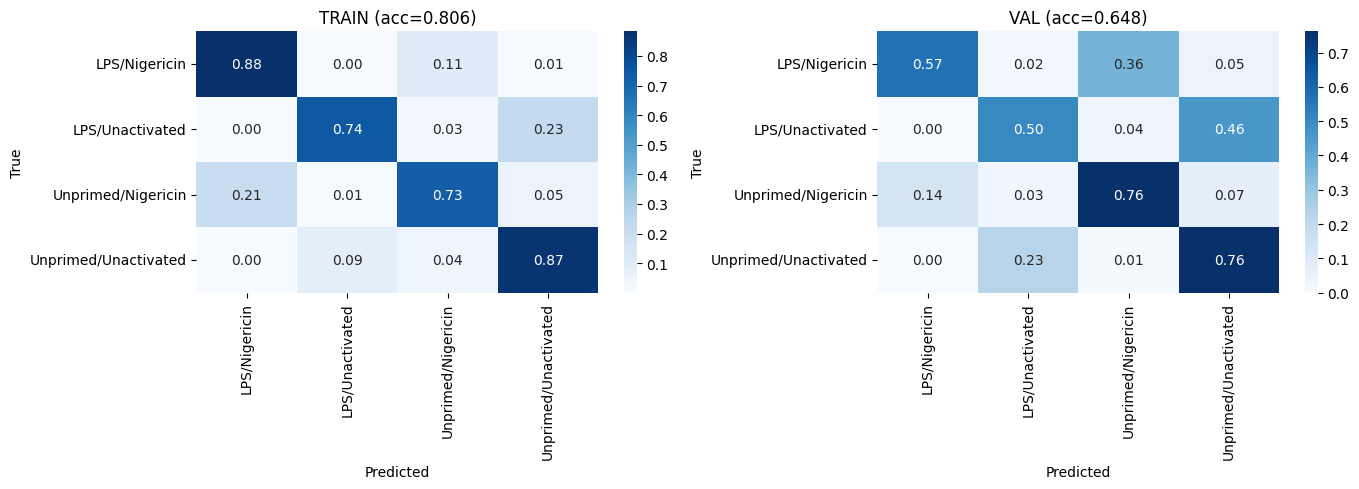

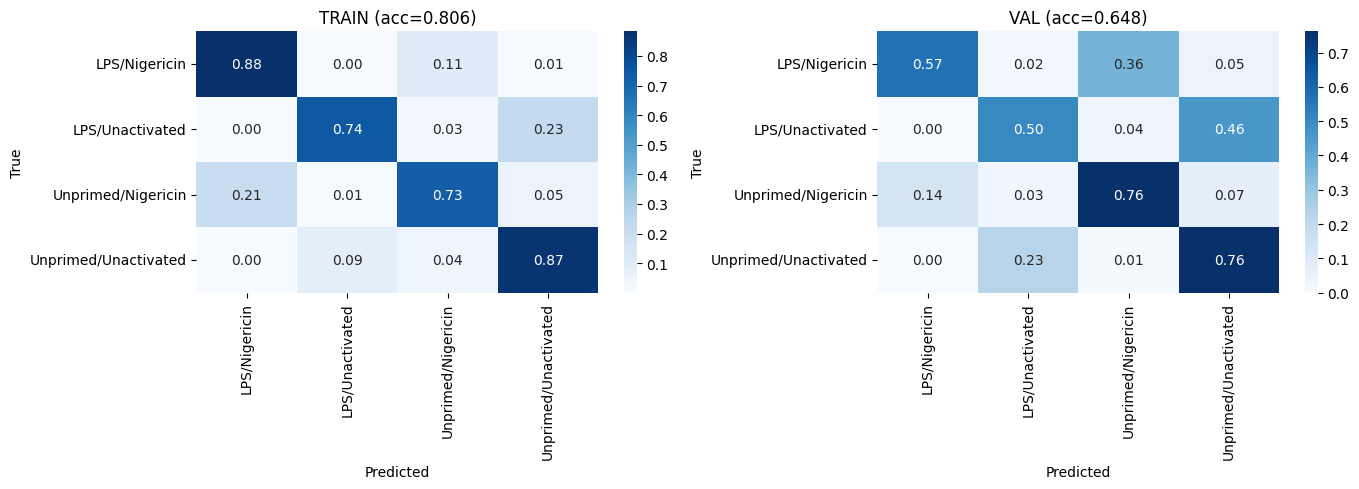

In [11]:
# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, labels_arr, title in [
    (axes[0], train_preds, train_labels_arr, f'TRAIN (acc={train_acc:.3f})'),
    (axes[1], val_preds, val_labels_arr, f'VAL (acc={val_acc:.3f})'),
]:
    cm = confusion_matrix(labels_arr, preds)
    # Normalize by row (true label)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=label_encoder.classes,
        yticklabels=label_encoder.classes,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

## Per-class Confidence Analysis
Check if the model is confident on train samples (high probability for correct class)

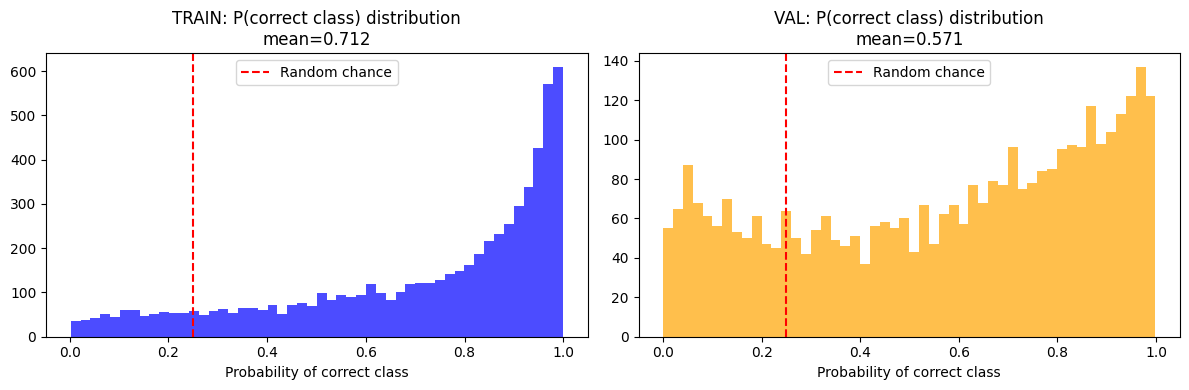


Train mean confidence (correct class): 0.712
Val mean confidence (correct class):   0.571


In [12]:
# Confidence of correct class
train_correct_probs = train_probs[np.arange(len(train_labels_arr)), train_labels_arr]
val_correct_probs = val_probs[np.arange(len(val_labels_arr)), val_labels_arr]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_correct_probs, bins=50, alpha=0.7, color='blue')
axes[0].set_title(f'TRAIN: P(correct class) distribution\nmean={train_correct_probs.mean():.3f}')
axes[0].set_xlabel('Probability of correct class')
axes[0].axvline(x=1.0/label_encoder.num_classes, color='red', linestyle='--', label='Random chance')
axes[0].legend()

axes[1].hist(val_correct_probs, bins=50, alpha=0.7, color='orange')
axes[1].set_title(f'VAL: P(correct class) distribution\nmean={val_correct_probs.mean():.3f}')
axes[1].set_xlabel('Probability of correct class')
axes[1].axvline(x=1.0/label_encoder.num_classes, color='red', linestyle='--', label='Random chance')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nTrain mean confidence (correct class): {train_correct_probs.mean():.3f}")
print(f"Val mean confidence (correct class):   {val_correct_probs.mean():.3f}")